<a href="https://colab.research.google.com/github/boganast2206/stat_pract/blob/main/happiness_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Сравнительный анализ регрессионных моделей для предсказания уровня счастья по данным World Happiness Report:
https://www.kaggle.com/datasets/obaidhere/world-happiness-report?select=2019.csv

**Автор:** Богачева Анастасия

**Группа:** 331

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor


import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv('datasets/2019.csv')

In [ ]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('or', 'or')
print("Новые названия признаков:")
print(df.columns.tolist()) # для проверки, что мы ввели нижние подчеркивания

features = [
    'GDP_per_capita',
    'Social_support',
    'Healthy_life_expectancy',
    'Freedom_to_make_life_choices',
    'Generosity',
    'Perceptions_of_corruption'
]
target = 'Score'

X = df[features]
y = df[target]

Новые названия признаков:
['Overall_rank', 'Country_or_region', 'Score', 'GDP_per_capita', 'Social_support', 'Healthy_life_expectancy', 'Freedom_to_make_life_choices', 'Generosity', 'Perceptions_of_corruption']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED
)

print(f"Размер обучающей выборки: {X_train.shape[0]} стран")
print(f"Размер тестовой выборки:    {X_test.shape[0]} стран")

Размер обучающей выборки: 124 стран
Размер тестовой выборки:    32 стран


# Вывод:

Мы загрузили датасет из CSV‑файла, навели порядок в названиях столбцов и определили, что будем предсказывать Score на основе шести числовых признаков. Затем данные разделили на обучающую (80%) и тестовую (20%) выборки, чтобы позже обучить модели на одной части и объективно проверить их качество на другой.

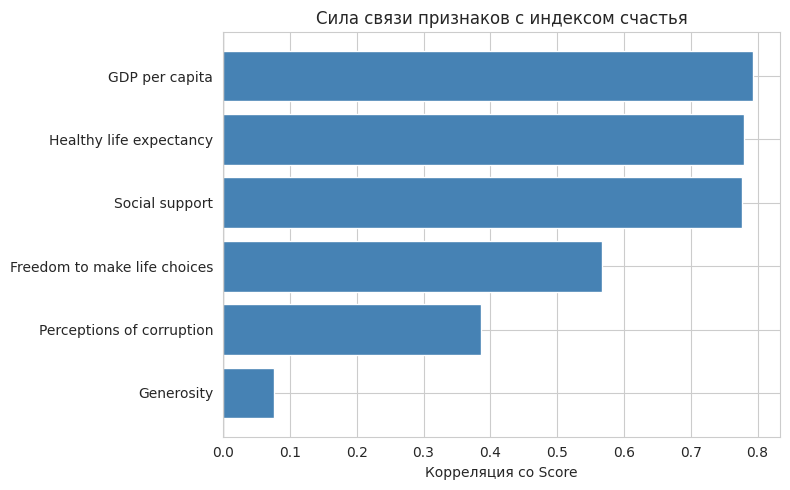

Корреляции со Score:
  Generosity: 0.076
  Perceptions of corruption: 0.386
  Freedom to make life choices: 0.567
  Social support: 0.777
  Healthy life expectancy: 0.780
  GDP per capita: 0.794


In [ ]:
corr_with_target = df[features + ['Score']].corr()['Score'].drop('Score').sort_values()
corr_with_target.index = corr_with_target.index.str.replace('_', ' ')

plt.figure(figsize=(8, 5))
bars = plt.barh(corr_with_target.index, corr_with_target.values, color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Корреляция со Score')
plt.title('Сила связи признаков с индексом счастья')
plt.tight_layout()
plt.show()

print("Корреляции со Score:")
for feature, value in corr_with_target.items():
    print(f"  {feature}: {value:.3f}")

# Вывод:
Сильнее всего c индексом счастья Score связаны Social support (уровень социальной поддержки), Healthy life expectancy (ожидаемая продолжительность жизни без серьёзных заболеваний) и GDP per capita (ВВП на душу населения). Именно их мы будем рассматривать как ключевые признаки, потому что они лучше всего объясняют изменения в уровне счастья между странами.


# Первой моделью берём Linear Regression (линейную регрессию).

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) ## масштабирование

In [ ]:
lr_all = LinearRegression()
lr_all.fit(X_train_scaled, y_train)
y_pred_all = lr_all.predict(X_test_scaled)

mse_all = mean_squared_error(y_test, y_pred_all)
r2_all = r2_score(y_test, y_pred_all)
print("Линейная регрессия:")
print(f"Test MSE = {mse_all:.4f}, R² = {r2_all:.4f}")

Линейная регрессия:
Test MSE = 0.4145, R² = 0.6018


Попробуем сократить количество признаков до трёх ключевых - Social support, Healthy life expectancy и GDP per capita. Именно они показали самую сильную связь с индексом счастья в нашем корреляционном анализе и EDA.

In [ ]:
features_reduced = [
    'GDP_per_capita',
    'Social_support',
    'Healthy_life_expectancy',
]

X_red = df[features_reduced]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_red, y, test_size=0.2, random_state=SEED)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

lr_red = LinearRegression()
lr_red.fit(X_train_r_scaled, y_train_r)
y_pred_red = lr_red.predict(X_test_r_scaled)

mse_red = mean_squared_error(y_test_r, y_pred_red)
r2_red = r2_score(y_test_r, y_pred_red)

print("Линейная регрессия (3 признака):")
print(f"Test MSE = {mse_red:.4f}, R² = {r2_red:.4f}")

Линейная регрессия (3 признака):
Test MSE = 0.4637, R² = 0.5545


Вывод: показатели явно ухудшились, потому что линейная регрессия потеряла часть полезной информации. Оставшиеся признаки действительно самые сильные, но исключённые (Freedom, Generosity, Corruption) всё же вносили небольшой, но полезный вклад.

Удалим из обучающей выборки страны-выбросы и проверим, улучшится ли точность линейной регрессии.

In [ ]:
lr_out = LinearRegression()
lr_out.fit(X_train_scaled, y_train)

train_pred = lr_out.predict(X_train_scaled)
residuals = np.abs(y_train - train_pred)

threshold = residuals.mean() + 2 * residuals.std()
outlier_mask = residuals > threshold

X_train_clean = X_train_scaled[~outlier_mask]
y_train_clean = y_train[~outlier_mask]

lr_clean = LinearRegression()
lr_clean.fit(X_train_clean, y_train_clean)

y_pred_clean = lr_clean.predict(X_test_scaled)

mse_clean = mean_squared_error(y_test, y_pred_clean)
r2_clean = r2_score(y_test, y_pred_clean)

y_pred_old = lr_out.predict(X_test_scaled)
mse_old = mean_squared_error(y_test, y_pred_old)
r2_old = r2_score(y_test, y_pred_old)
print("Линейная регрессия после удаления:")
print(f"MSE = {mse_clean:.4f}, R² = {r2_clean:.4f}")

Линейная регрессия после удаления:
MSE = 0.4142, R² = 0.6020


Вывод: удаление нескольких наиболее трудных для модели стран позволило линейной регрессии точнее уловить общую закономерность. Без этих выбросов модель стала меньше подстраиваться под единичные аномалии и лучше описывать типичные страны, поэтому ошибка снизилась, а R² немного вырос.

Добавим полиномиальные признаки, чтобы модель могла улавливать нелинейные связи.

Возьмем степень 2:

In [ ]:

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_poly_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_poly_scaled)
mse_ridge_two = mean_squared_error(y_test, y_pred_ridge)
r2_ridge_two = r2_score(y_test, y_pred_ridge)

print("Ridge-регрессия с полиномиальными признаками (степень 2):")
print(f"MSE = {mse_ridge_two:.4f}, R² = {r2_ridge_two:.4f}")
print(f"Выбранный alpha: {ridge.alpha_:.2f}")

Ridge-регрессия с полиномиальными признаками (степень 2):
MSE = 0.3528, R² = 0.6610
Выбранный alpha: 10.00


Вывод: метрики улучшились по сравнению с обычной линейной регрессией. Попробуем полиномиальные признаки степени 3.



In [ ]:
poly = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_poly_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_poly_scaled)
mse_ridge_three = mean_squared_error(y_test, y_pred_ridge)
r2_ridge_three = r2_score(y_test, y_pred_ridge)

print("Ridge-регрессия с полиномиальными признаками (степень 3):")
print(f"MSE = {mse_ridge_three:.4f}, R² = {r2_ridge_three:.4f}")
print(f"Выбранный alpha: {ridge.alpha_}")

Ridge-регрессия с полиномиальными признаками (степень 3):
MSE = 0.3351, R² = 0.6780
Выбранный alpha: 10.0


Вывод: метрики улучшились по сравнению с обычной линейной регрессией и с Ridge-регрессией с полиномиальными признаками (степень 2). Попробуем полиномиальные признаки степени 4.

In [ ]:
poly = PolynomialFeatures(degree=4, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)
/
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_poly_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_poly_scaled)
mse_ridge_four = mean_squared_error(y_test, y_pred_ridge)
r2_ridge_four = r2_score(y_test, y_pred_ridge)

print("Ridge-регрессия с полиномиальными признаками (степень 4):")
print(f"Test MSE = {mse_ridge_four:.4f}, R² = {r2_ridge_four:.4f}")
print(f"Выбранный alpha: {ridge.alpha_}")

Ridge-регрессия с полиномиальными признаками (степень 4):
Test MSE = 0.3374, R² = 0.6758
Выбранный alpha: 10.0


Вывод: показатели ухудшились по сравнению с Ridge-регрессией с полиномиальными признаками (степень 3). При переходе к степени 4 количество признаков резко возрастает, модель начинает подстраиваться под случайный шум в обучающей выборке, и качество на тесте падает. Поэтому оптимальный баланс между гибкостью и обобщающей способностью достигается именно при степени 3.

После того как удаление выбросов улучшило обычную линейную регрессию, а полиномы степени 3 дали лучший результат для Ridge, я решила объединить эти две идеи. Сейчас мы построим Ridge‑регрессию на полиномиальных признаках степени 3, затем удалим из обучающей выборки страны с самыми большими ошибками и переобучим модель. Так мы одновременно используем нелинейные закономерности и очищаем данные от аномалий.

In [ ]:
poly3 = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_test_poly3_scaled = scaler_poly3.transform(X_test_poly3)

ridge_all = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_all.fit(X_train_poly3_scaled, y_train)

train_pred_all = ridge_all.predict(X_train_poly3_scaled)
residuals3 = np.abs(y_train - train_pred_all)

threshold3 = residuals3.mean() + 2 * residuals3.std()
outlier_mask3 = residuals3 > threshold3

X_train_clean3 = X_train_poly3_scaled[~outlier_mask3]
y_train_clean3 = y_train[~outlier_mask3]

ridge_clean3 = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_clean3.fit(X_train_clean3, y_train_clean3)

y_pred_clean3 = ridge_clean3.predict(X_test_poly3_scaled)
mse_clean3 = mean_squared_error(y_test, y_pred_clean3)
r2_clean3 = r2_score(y_test, y_pred_clean3)

y_pred_all3 = ridge_all.predict(X_test_poly3_scaled)
mse_all3 = mean_squared_error(y_test, y_pred_all3)
r2_all3 = r2_score(y_test, y_pred_all3)

print("\nRidge (степень 3) после удаления выбросов:")
print(f"MSE = {mse_clean3:.4f}, R² = {r2_clean3:.4f}")
print(f"Выбранный alpha: {ridge_clean3.alpha_:.2f}")


Ridge (степень 3) после удаления выбросов:
MSE = 0.3224, R² = 0.6902
Выбранный alpha: 100.00


Моя гипотеза подтвердилась: объединение Ridge‑регрессии с полиномами степени 3 и удаления выбросов дало наилучший результат среди всех опробованных вариантов. Модель стала точнее предсказывать индекс счастья на тестовой выборке.

Попробуем Lasso‑регрессию с полиномиальными признаками.

In [ ]:
poly3 = PolynomialFeatures(degree=3, interaction_only=False, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_test_poly3_scaled = scaler_poly3.transform(X_test_poly3)

lasso3 = LassoCV(cv=5, random_state=SEED, max_iter=10000)
lasso3.fit(X_train_poly3_scaled, y_train)

y_pred_lasso3 = lasso3.predict(X_test_poly3_scaled)
mse_lasso3 = mean_squared_error(y_test, y_pred_lasso3)
r2_lasso3 = r2_score(y_test, y_pred_lasso3)

print("Lasso-регрессия с полиномиальными признаками (степень 3):")
print(f"Test MSE = {mse_lasso3:.4f}, R² = {r2_lasso3:.4f}")
print(f"Выбранный alpha: {lasso3.alpha_:.4f}")

coef_lasso3 = pd.Series(lasso3.coef_, index=poly3.get_feature_names_out())
n_nonzero3 = (coef_lasso3 != 0).sum()
print(f"Количество ненулевых коэффициентов: {n_nonzero3} из {len(coef_lasso3)}")

Lasso-регрессия с полиномиальными признаками (степень 3):
Test MSE = 0.3584, R² = 0.6556
Выбранный alpha: 0.0014
Количество ненулевых коэффициентов: 30 из 83


Вывод: Lasso‑регрессия отработала значительно лучше обычной линейной регрессии, но всё же показала результат хуже, чем лучшая модель - Ridge с полиномами степени 3 после удаления выбросов.

In [ ]:
all_results = pd.DataFrame({
    'Модель': [
        'Linear (6 признаков)',
        'Linear (3 признака)',
        'Linear (6 признаков) с удалением выбросов',
        'Ridge + полиномы (степень 2)',
        'Ridge + полиномы (степень 3)',
        'Ridge + полиномы (степень 4)',
        'Ridge + полиномы (степень 3) с удалением выбросов',
        'Lasso + полиномы'
    ],
    'MSE': [mse_all, mse_red, mse_clean, mse_ridge_two, mse_ridge_three, mse_ridge_four, mse_clean3, mse_lasso3],
    'R²': [r2_all, r2_red, r2_ridge_two, r2_clean, r2_ridge_three, r2_ridge_four, r2_clean3, r2_lasso3]
})

print("Сравнение всех моделей на тестовой выборке:")
print(all_results.round(8))

Сравнение всех моделей на тестовой выборке:
                                              Модель       MSE        R²
0                               Linear (6 признаков)  0.414464  0.601754
1                                Linear (3 признака)  0.463688  0.554456
2          Linear (6 признаков) с удалением выбросов  0.414220  0.660988
3                       Ridge + полиномы (степень 2)  0.352817  0.601988
4                       Ridge + полиномы (степень 3)  0.335147  0.677967
5                       Ridge + полиномы (степень 4)  0.337382  0.675820
6  Ridge + полиномы (степень 3) с удалением выбросов  0.322429  0.690188
7                                   Lasso + полиномы  0.358394  0.655630


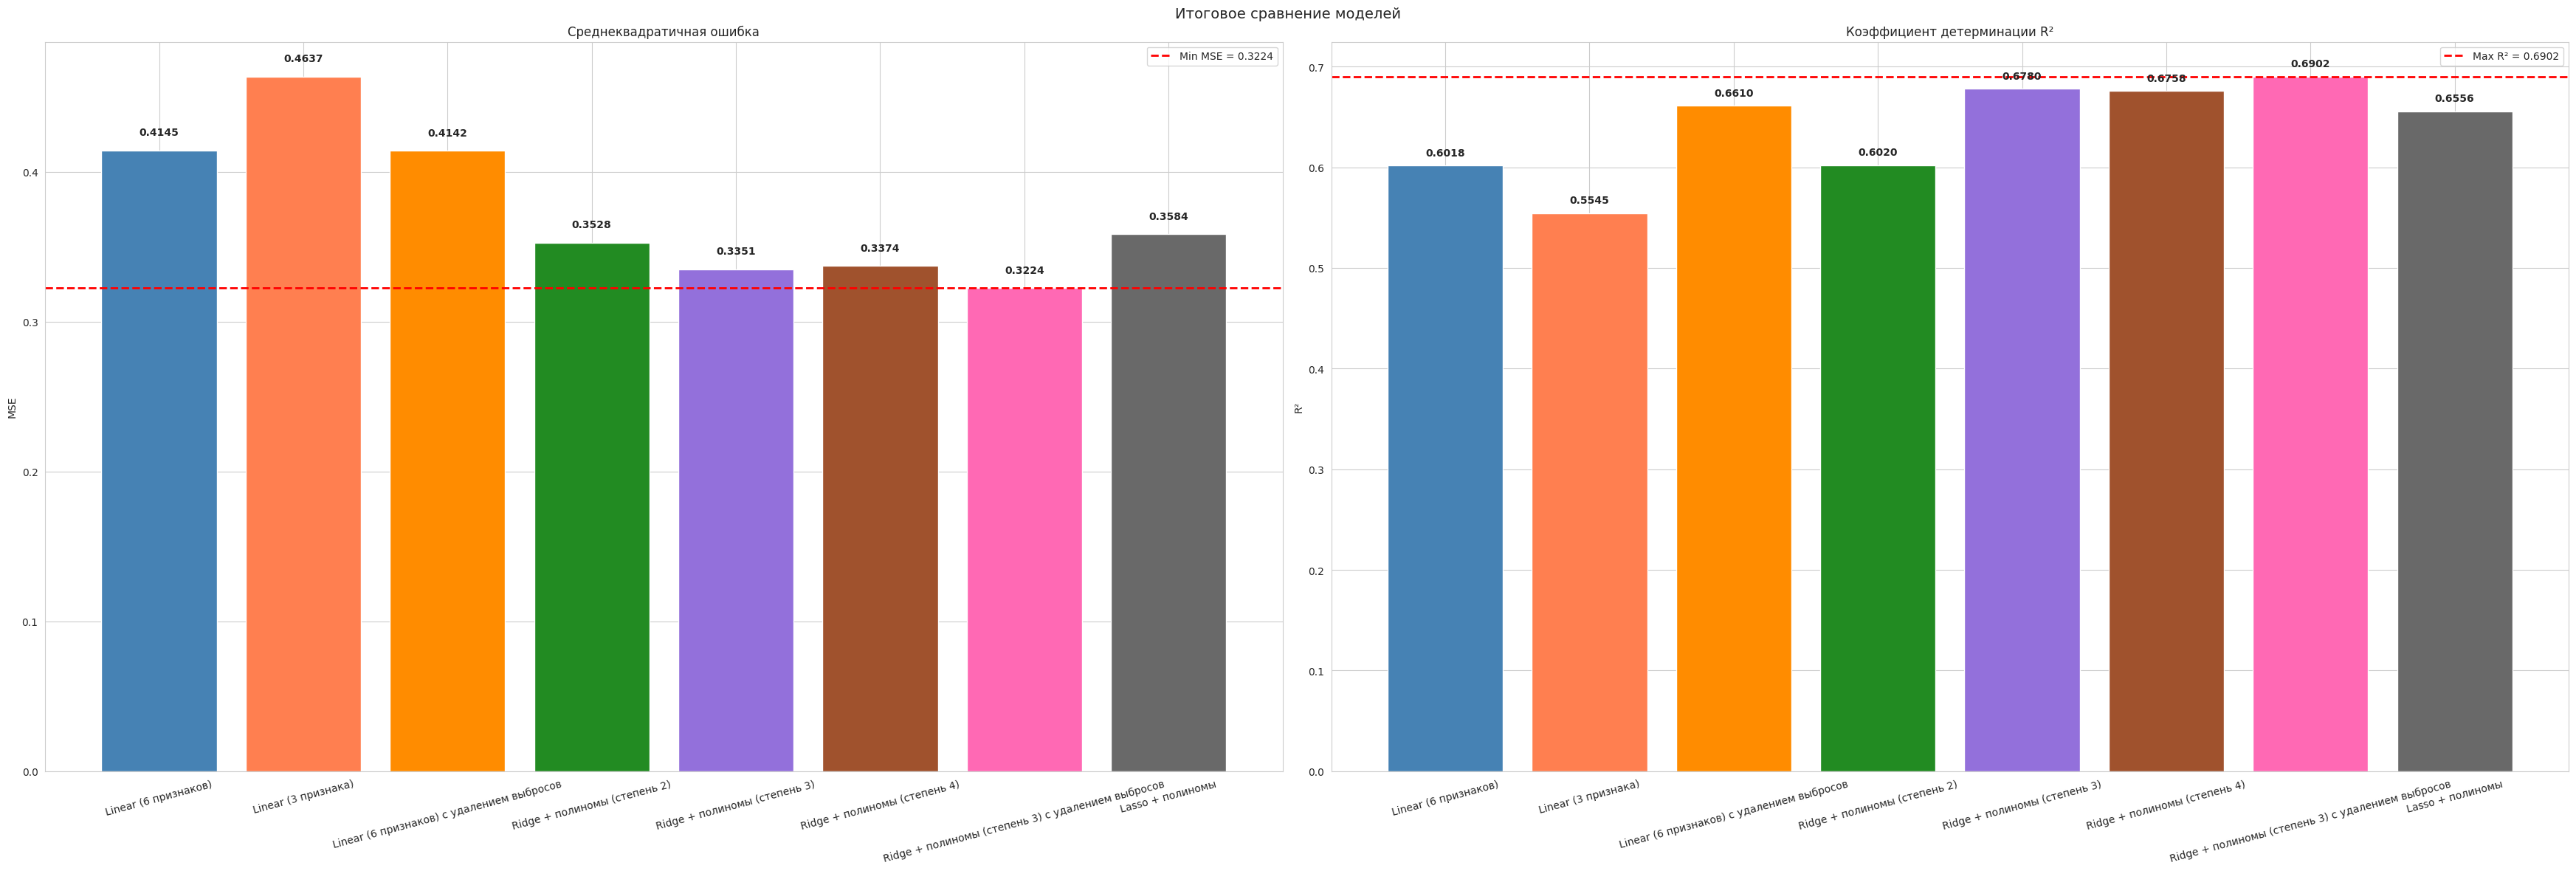

In [ ]:
min_mse = all_results['MSE'].min()
max_r2 = all_results['R²'].max()

fig, axes = plt.subplots(1, 2, figsize=(35, 12))

axes[0].bar(all_results['Модель'], all_results['MSE'],
            color=['steelblue',
    'coral',
    'darkorange',
    'forestgreen',
    'mediumpurple',
    'sienna',
    'hotpink',
    'dimgray'])
axes[0].set_ylabel('MSE')
axes[0].set_title('Среднеквадратичная ошибка')
axes[0].tick_params(axis='x', rotation=15)

axes[0].axhline(y=min_mse, color='red', linestyle='--', linewidth=2, label=f'Min MSE = {min_mse:.4f}')

axes[1].bar(all_results['Модель'], all_results['R²'],
            color=['steelblue',
    'coral',
    'darkorange',
    'forestgreen',
    'mediumpurple',
    'sienna',
    'hotpink',
    'dimgray'])
axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации R²')
axes[1].tick_params(axis='x', rotation=15)

axes[1].axhline(y=max_r2, color='red', linestyle='--', linewidth=2, label=f'Max R² = {max_r2:.4f}')

for ax in axes:
    for i, v in enumerate(ax.patches):
        ax.text(i, v.get_height() + 0.01, f'{v.get_height():.4f}',
                ha='center', fontweight='bold')
    ax.legend()

plt.suptitle('Итоговое сравнение моделей', fontsize=14)
plt.tight_layout()
plt.show()

# Вывод:

Мы провели серию экспериментов с линейной регрессией: обучили базовую модель, попробовали сократить число признаков, удалили выбросы, добавили полиномиальные признаки и регуляризацию (Ridge, Lasso). Лучший результат показала Ridge-регрессия на полиномах степени 3 с предварительным удалением выбросов - она дала минимальную ошибку и максимальный R² среди всех линейных моделей. Это подтверждает, что в данных есть нелинейные зависимости, а регуляризация помогает их уловить без переобучения. Обычная линейная регрессия и Lasso уступили, как и попытки сократить признаки до трёх ключевых.

# Воторой моделью рассмотрим K‑Nearest Neighbors (KNN).

In [ ]:
features_knn = [
    'GDP_per_capita',
    'Social_support',
    'Healthy_life_expectancy',
    'Freedom_to_make_life_choices',
    'Generosity',
    'Perceptions_of_corruption'
]

X_knn = df[features_knn]
y_knn = df['Score']

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=SEED
)

scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn = KNeighborsRegressor()
knn.fit(X_train_knn_scaled, y_train_knn)

y_pred_knn = knn.predict(X_test_knn_scaled)

mse_knn = mean_squared_error(y_test_knn, y_pred_knn)
r2_knn = r2_score(y_test_knn, y_pred_knn)

print("KNN:")
print(f"MSE = {mse_knn:.4f}, R² = {r2_knn:.4f}")

KNN:
MSE = 0.4489, R² = 0.5687


Вывод: обычный KNN с параметрами по умолчанию (5 соседей, равномерные веса, евклидово расстояние) показал более высокую ошибку и более низкий R² по сравнению с лучшей линейной моделью.

Обычный KNN с параметрами по умолчанию не дал хорошего результата, но мы можем попробовать улучшить его, подобрав оптимальное число соседей, веса и метрику расстояния. Для этого перебираем комбинации гиперпараметров с помощью GridSearchCV и кросс‑валидации, чтобы найти наилучшую конфигурацию.

In [ ]:
knn = KNeighborsRegressor()

param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

grid_knn = GridSearchCV(
    knn,
    param_grid,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_knn.fit(X_train_knn_scaled, y_train_knn)

print("Лучшие параметры KNN:", grid_knn.best_params_)
print("Лучший MSE (кросс-валидация): {:.4f}\n".format(-grid_knn.best_score_))

knn_best = grid_knn.best_estimator_
knn_best.fit(X_train_knn_scaled, y_train_knn)

y_pred_best = knn_best.predict(X_test_knn_scaled)
mse_best = mean_squared_error(y_test_knn, y_pred_best)
r2_best = r2_score(y_test_knn, y_pred_best)

print("Лучший KNN (подобранные параметры):")
print(f"MSE = {mse_best:.4f}, R² = {r2_best:.4f}")

Лучшие параметры KNN: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Лучший MSE (кросс-валидация): 0.2794

Лучший KNN (подобранные параметры):
MSE = 0.4339, R² = 0.5831


Подбор параметров позволил немного улучшить KNN по сравнению с версией по умолчанию, но итоговые метрики всё равно уступают нашей лучшей линейной модели (Ridge со степенью 3 и удалением выбросов).

Обучим KNN только на трёх самых сильных признаках, убрав лишний шум.

In [ ]:
features_sel = [
    'GDP_per_capita',
    'Social_support',
    'Healthy_life_expectancy'
]

X_sel = df[features_sel]
y_sel = df['Score']

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel, y_sel, test_size=0.2, random_state=SEED
)

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

param_grid_sel = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
grid_sel = GridSearchCV(KNeighborsRegressor(), param_grid_sel,
                        cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
grid_sel.fit(X_train_sel_scaled, y_train_sel)

best_knn_sel = grid_sel.best_estimator_
y_pred_sel = best_knn_sel.predict(X_test_sel_scaled)

mse_sel = mean_squared_error(y_test_sel, y_pred_sel)
r2_sel = r2_score(y_test_sel, y_pred_sel)

print("KNN с отбором признаков (3 признака):")
print(f"Лучшие параметры: {grid_sel.best_params_}")
print(f"Test MSE = {mse_sel:.4f}, R² = {r2_sel:.4f}")

KNN с отбором признаков (3 признака):
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'uniform'}
Test MSE = 0.4196, R² = 0.5968


Вывод: модель стала немного точнее, но всё равно проигрывает лучшей линейной модели.

Удалим выбросы и подберём гиперпараметры KNN - возможно, так модель станет точнее.

In [ ]:
knn_base = KNeighborsRegressor(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
train_pred = knn_base.predict(X_train_scaled)

residuals = np.abs(y_train - train_pred)
threshold = residuals.mean() + 2 * residuals.std()
outlier_mask = residuals > threshold

print(f"Выбросов найдено: {outlier_mask.sum()} из {len(y_train)}")

X_train_clean = X_train_scaled[~outlier_mask]
y_train_clean = y_train[~outlier_mask]

knn_clean = KNeighborsRegressor()
grid_clean = GridSearchCV(knn_clean, param_grid,
                          cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
                          scoring='neg_mean_squared_error', n_jobs=-1)
grid_clean.fit(X_train_clean, y_train_clean)

best_knn_clean = grid_clean.best_estimator_
y_pred_clean = best_knn_clean.predict(X_test_scaled)

mse_clean = mean_squared_error(y_test, y_pred_clean)
r2_clean = r2_score(y_test, y_pred_clean)

print("KNN после удаления выбросов:")
print(f"Лучшие параметры: {grid_clean.best_params_}")
print(f"Test MSE = {mse_clean:.4f}, R² = {r2_clean:.4f}")


Выбросов найдено: 7 из 124
KNN после удаления выбросов:
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Test MSE = 0.4208, R² = 0.5957


Вывод: KNN после очистки и подбора параметров дал MSE и R² лучше, чем обычный KNN, но всё ещё хуже, чем лучшая линейная модель. Ridge с полиномами степени 3 и удалением выбросов остаётся самым точным.



Объединим три улучшения для KNN: оставим только три ключевых признака, удалим выбросы и применим ранее найденные лучшие гиперпараметры. Посмотрим, даст ли это более точную модель.

In [ ]:

features_3 = ['GDP_per_capita', 'Social_support', 'Healthy_life_expectancy']
X3 = df[features_3]
y3 = df['Score']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=SEED
)

scaler3 = StandardScaler()
X_train3_scaled = scaler3.fit_transform(X_train3)
X_test3_scaled = scaler3.transform(X_test3)

knn_base = KNeighborsRegressor(n_neighbors=5)
knn_base.fit(X_train3_scaled, y_train3)
train_pred3 = knn_base.predict(X_train3_scaled)
residuals3 = np.abs(y_train3 - train_pred3)

threshold3 = residuals3.mean() + 2 * residuals3.std()
outlier_mask3 = residuals3 > threshold3
print(f"Выбросов удалено: {outlier_mask3.sum()} из {len(y_train3)}")

X_train3_clean = X_train3_scaled[~outlier_mask3]
y_train3_clean = y_train3[~outlier_mask3]

best_knn_top3 = KNeighborsRegressor(
    n_neighbors=11,
    weights='distance',
    metric='manhattan'
)
best_knn_top3.fit(X_train3_clean, y_train3_clean)
y_pred_top3 = best_knn_top3.predict(X_test3_scaled)

mse_top3 = mean_squared_error(y_test3, y_pred_top3)
r2_top3 = r2_score(y_test3, y_pred_top3)

print("\nЛучшая KNN (3 признака, без выбросов):")
print(f"Test MSE = {mse_top3:.4f}, R² = {r2_top3:.4f}")

Выбросов удалено: 6 из 124

Лучшая KNN (3 признака, без выбросов):
Test MSE = 0.3880, R² = 0.6272


Вывод: KNN с тремя признаками и очисткой от выбросов показал наилучший результат среди всех KNN‑экспериментов, но всё равно не превзошёл лучшую Ridge‑модель.

In [ ]:
all_knn = pd.DataFrame({
    'Модель': [
        'KNN',
        'KNN (подбор параметров)',
        'KNN (3 признака)',
        'KNN (удаление выбросов)',
        'KNN (3 признака, без выбросов)'
    ],
    'MSE': [mse_knn, mse_best, mse_sel, mse_clean, mse_top3],
    'R²':   [r2_knn, r2_best, r2_sel, r2_clean, r2_top3]
})

print("Сравнение моделей KNN на тестовой выборке:")
print(all_knn.round(4))

Сравнение моделей KNN на тестовой выборке:
                           Модель     MSE      R²
0                             KNN  0.4489  0.5687
1         KNN (подбор параметров)  0.4339  0.5831
2                KNN (3 признака)  0.4196  0.5968
3         KNN (удаление выбросов)  0.4208  0.5957
4  KNN (3 признака, без выбросов)  0.3880  0.6272


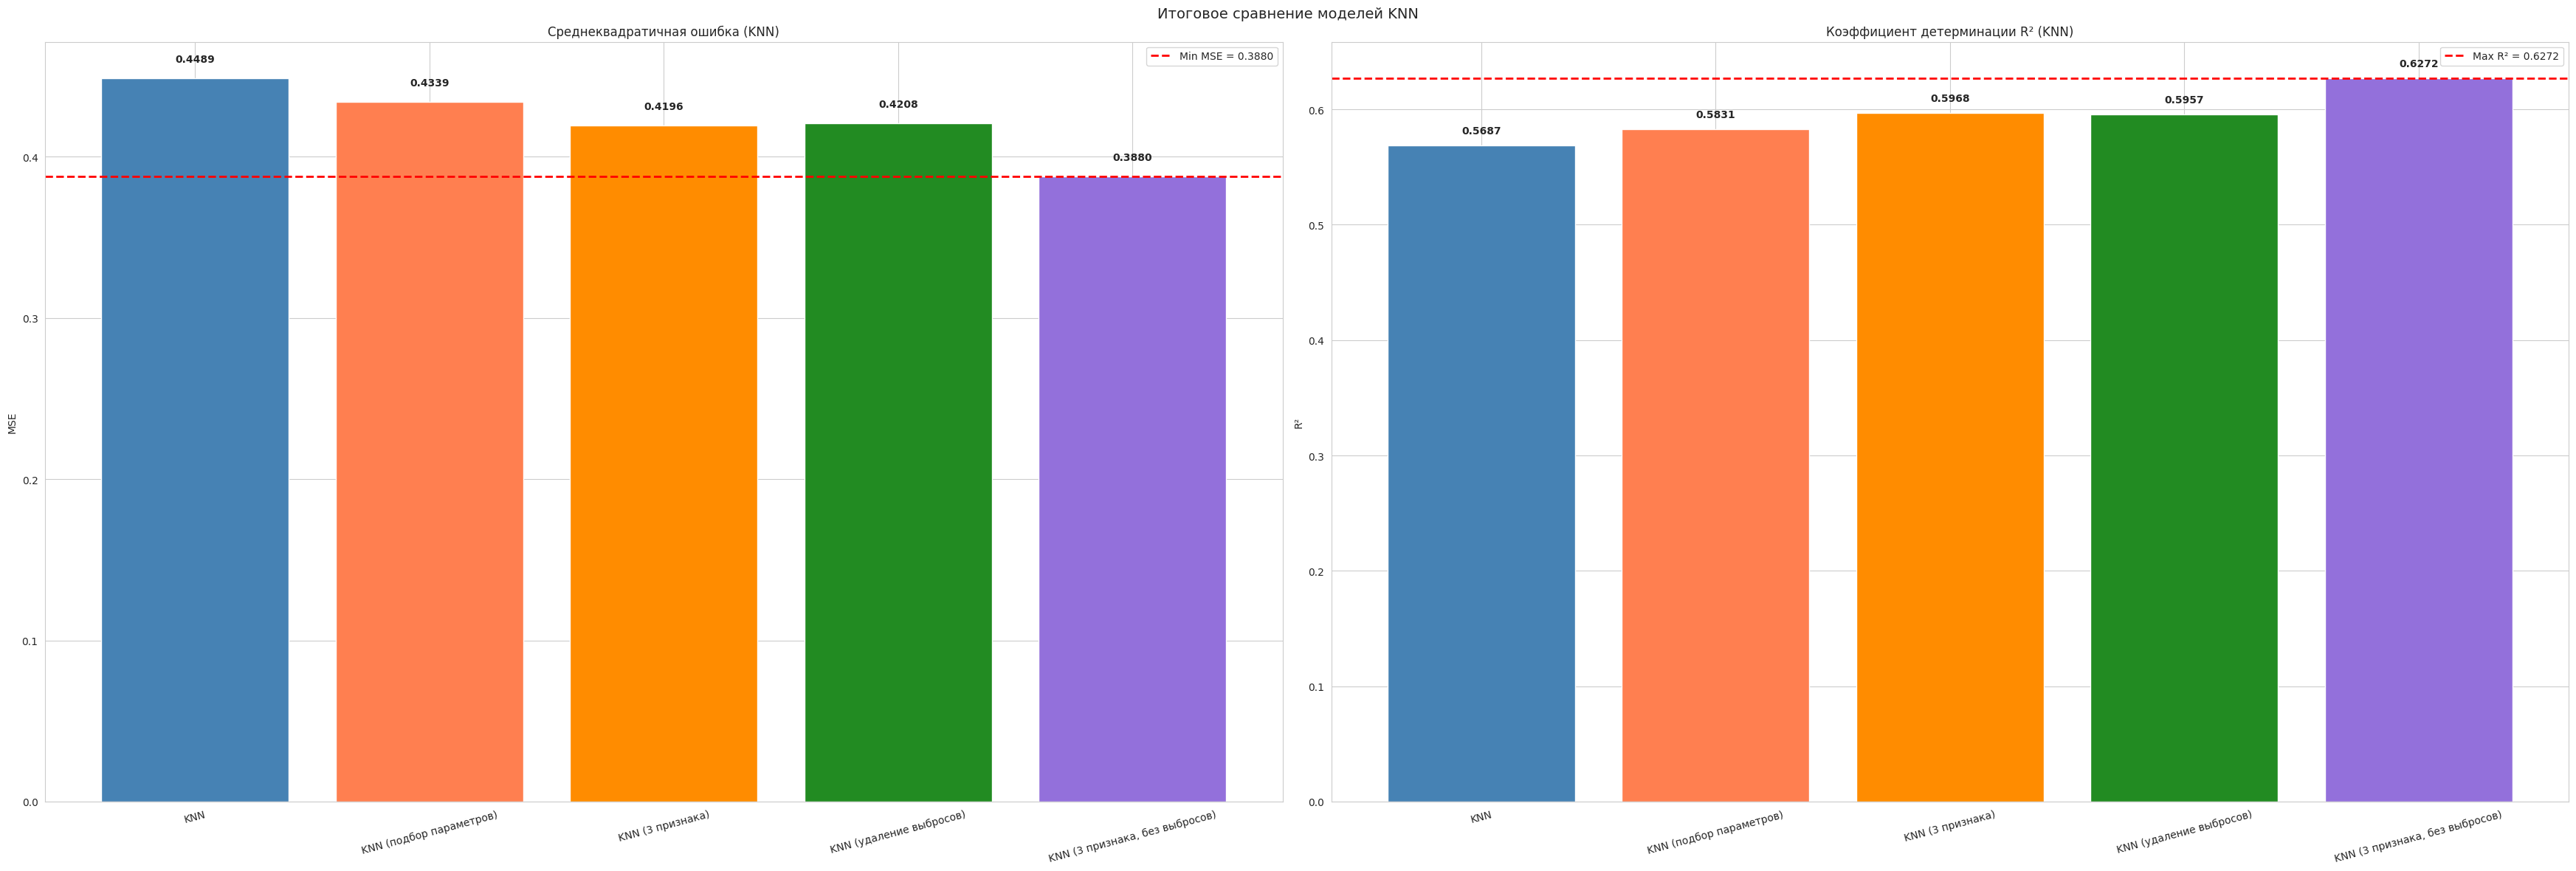

In [ ]:
min_mse_knn = all_knn['MSE'].min()
max_r2_knn = all_knn['R²'].max()

fig, axes = plt.subplots(1, 2, figsize=(35, 12))

colors = ['steelblue', 'coral', 'darkorange', 'forestgreen', 'mediumpurple']

axes[0].bar(all_knn['Модель'], all_knn['MSE'], color=colors)
axes[0].set_ylabel('MSE')
axes[0].set_title('Среднеквадратичная ошибка (KNN)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(y=min_mse_knn, color='red', linestyle='--', linewidth=2, label=f'Min MSE = {min_mse_knn:.4f}')

axes[1].bar(all_knn['Модель'], all_knn['R²'], color=colors)
axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации R² (KNN)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=max_r2_knn, color='red', linestyle='--', linewidth=2, label=f'Max R² = {max_r2_knn:.4f}')

for ax in axes:
    for i, v in enumerate(ax.patches):
        ax.text(i, v.get_height() + 0.01, f'{v.get_height():.4f}',
                ha='center', fontweight='bold')
    ax.legend()

plt.suptitle('Итоговое сравнение моделей KNN', fontsize=14)
plt.tight_layout()
plt.show()

# Итог:
Мы последовательно улучшали KNN - подбирали параметры, отбирали признаки, удаляли выбросы. Лучшая версия достигла MSE=0.388, R²=0.627, но всё равно уступила регуляризованной полиномиальной регрессии. Причина - маленький датасет: KNN сильнее страдает от нехватки данных, тогда как линейные методы с регуляризацией обобщают точнее.



# Третьей моделью рассмотрим Random Forest (случайный лес).

In [ ]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

rf_default = RandomForestRegressor(random_state=SEED)
rf_default.fit(X_train_rf, y_train_rf)
y_pred_rf_default = rf_default.predict(X_test_rf)

mse_rf_def = mean_squared_error(y_test_rf, y_pred_rf_default)
r2_rf_def = r2_score(y_test_rf, y_pred_rf_default)

print("Random Forest:")
print(f"MSE = {mse_rf_def:.4f}, R² = {r2_rf_def:.4f}")

Random Forest:
MSE = 0.3864, R² = 0.6288


Вывод: базовый случайный лес уже обходит лучшие версии KNN, но пока не дотягивает до регуляризованной полиномиальной регрессии. Попробуем улучшить его подбором параметров.



In [ ]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
y_train_rf = y_train.copy()
y_test_rf = y_test.copy()

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=SEED)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5,
                       scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_rf, y_train_rf)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_rf)

mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("Random Forest (подбор параметров):")
print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Test MSE = {mse_rf:.4f}, R² = {r2_rf:.4f}")

Random Forest (подбор параметров):
Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Test MSE = 0.3801, R² = 0.6348


Вывод: подбор параметров немного улучшил Random Forest по сравнению с версией по умолчанию.

Сократим признаки до трёх самых сильных - GDP, Social support, Healthy life expectancy. Возможно, лес станет точнее, если убрать лишний шум.

In [ ]:
features_top3 = ['GDP_per_capita', 'Social_support', 'Healthy_life_expectancy']

X_train_3rf = X_train[features_top3]
X_test_3rf = X_test[features_top3]
y_train_3rf = y_train.copy()
y_test_3rf = y_test.copy()

rf3 = RandomForestRegressor(random_state=SEED)
grid_rf3 = GridSearchCV(rf3, param_grid_rf, cv=5,
                        scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf3.fit(X_train_3rf, y_train_3rf)

best_rf3 = grid_rf3.best_estimator_
y_pred_rf3 = best_rf3.predict(X_test_3rf)

mse_rf3 = mean_squared_error(y_test_3rf, y_pred_rf3)
r2_rf3 = r2_score(y_test_3rf, y_pred_rf3)

print("Random Forest (3 признака):")
print(f"Лучшие параметры: {grid_rf3.best_params_}")
print(f"Test MSE = {mse_rf3:.4f}, R² = {r2_rf3:.4f}")

Random Forest (3 признака):
Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Test MSE = 0.3889, R² = 0.6263


Вывод: сокращение признаков до трёх ключевых и подбор гиперпараметров не улучшили случайный лес - метрики остались примерно на уровне базовой версии. Модель всё ещё уступает лучшей линейной регрессии.

Удаление выбросов улучшало линейные модели - проверим, поможет ли этот же приём случайному лесу.

In [ ]:
rf_base = RandomForestRegressor(random_state=SEED)
rf_base.fit(X_train_rf, y_train_rf)
train_pred_rf = rf_base.predict(X_train_rf)

residuals_rf = np.abs(y_train_rf - train_pred_rf)
threshold_rf = residuals_rf.mean() + 2 * residuals_rf.std()
outlier_mask_rf = residuals_rf > threshold_rf

print(f"Выбросов удалено: {outlier_mask_rf.sum()} из {len(y_train_rf)}")

X_train_clean_rf = X_train_rf[~outlier_mask_rf]
y_train_clean_rf = y_train_rf[~outlier_mask_rf]

rf_clean = RandomForestRegressor(random_state=SEED)
grid_rf_clean = GridSearchCV(rf_clean, param_grid_rf, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf_clean.fit(X_train_clean_rf, y_train_clean_rf)

best_rf_clean = grid_rf_clean.best_estimator_
y_pred_rf_clean = best_rf_clean.predict(X_test_rf)

mse_rf_clean = mean_squared_error(y_test_rf, y_pred_rf_clean)
r2_rf_clean = r2_score(y_test_rf, y_pred_rf_clean)

print("Random Forest после удаления выбросов:")
print(f"Лучшие параметры: {grid_rf_clean.best_params_}")
print(f"Test MSE = {mse_rf_clean:.4f}, R² = {r2_rf_clean:.4f}")

Выбросов удалено: 7 из 124
Random Forest после удаления выбросов:
Лучшие параметры: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Test MSE = 0.3546, R² = 0.6593


Вывод: после удаления выбросов случайный лес достиг лучшего результата среди всех RF-экспериментов.

In [ ]:
all_rf = pd.DataFrame({
    'Модель': [
        'Random Forest (по умолчанию)',
        'Random Forest (подбор параметров)',
        'Random Forest (3 признака)',
        'Random Forest (удаление выбросов)'
    ],
    'MSE': [mse_rf_def, mse_rf, mse_rf3, mse_rf_clean],
    'R²':   [r2_rf_def, r2_rf, r2_rf3, r2_rf_clean]
})

print("Сравнение моделей Random Forest на тестовой выборке:")
print(all_rf.round(4))

Сравнение моделей Random Forest на тестовой выборке:
                              Модель     MSE      R²
0       Random Forest (по умолчанию)  0.3864  0.6288
1  Random Forest (подбор параметров)  0.3801  0.6348
2         Random Forest (3 признака)  0.3889  0.6263
3  Random Forest (удаление выбросов)  0.3546  0.6593


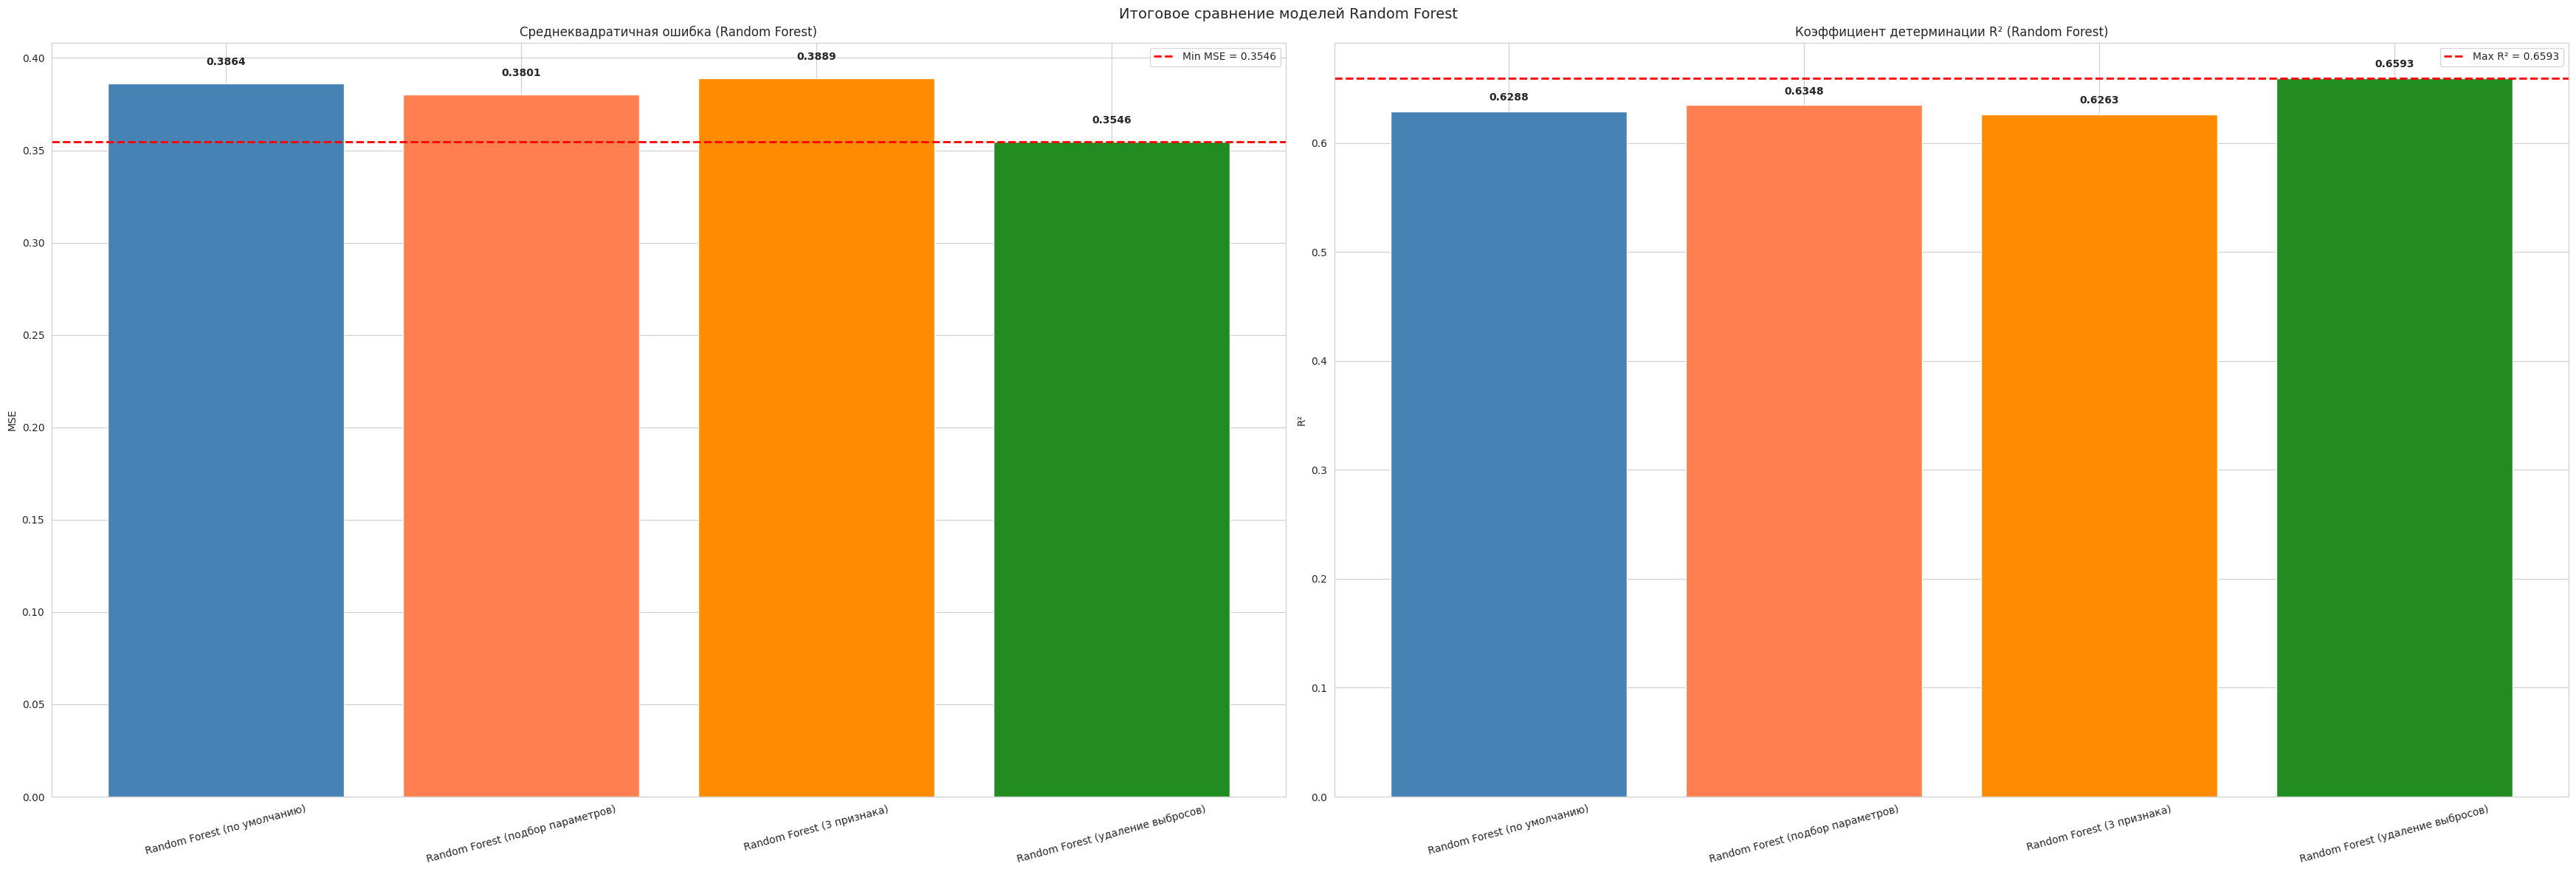

In [ ]:
min_mse_rf = all_rf['MSE'].min()
max_r2_rf = all_rf['R²'].max()

fig, axes = plt.subplots(1, 2, figsize=(35, 12))

colors = ['steelblue', 'coral', 'darkorange', 'forestgreen']

axes[0].bar(all_rf['Модель'], all_rf['MSE'], color=colors)
axes[0].set_ylabel('MSE')
axes[0].set_title('Среднеквадратичная ошибка (Random Forest)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(y=min_mse_rf, color='red', linestyle='--', linewidth=2, label=f'Min MSE = {min_mse_rf:.4f}')

axes[1].bar(all_rf['Модель'], all_rf['R²'], color=colors)
axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации R² (Random Forest)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=max_r2_rf, color='red', linestyle='--', linewidth=2, label=f'Max R² = {max_r2_rf:.4f}')

for ax in axes:
    for i, v in enumerate(ax.patches):
        ax.text(i, v.get_height() + 0.01, f'{v.get_height():.4f}',
                ha='center', fontweight='bold')
    ax.legend()

plt.suptitle('Итоговое сравнение моделей Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

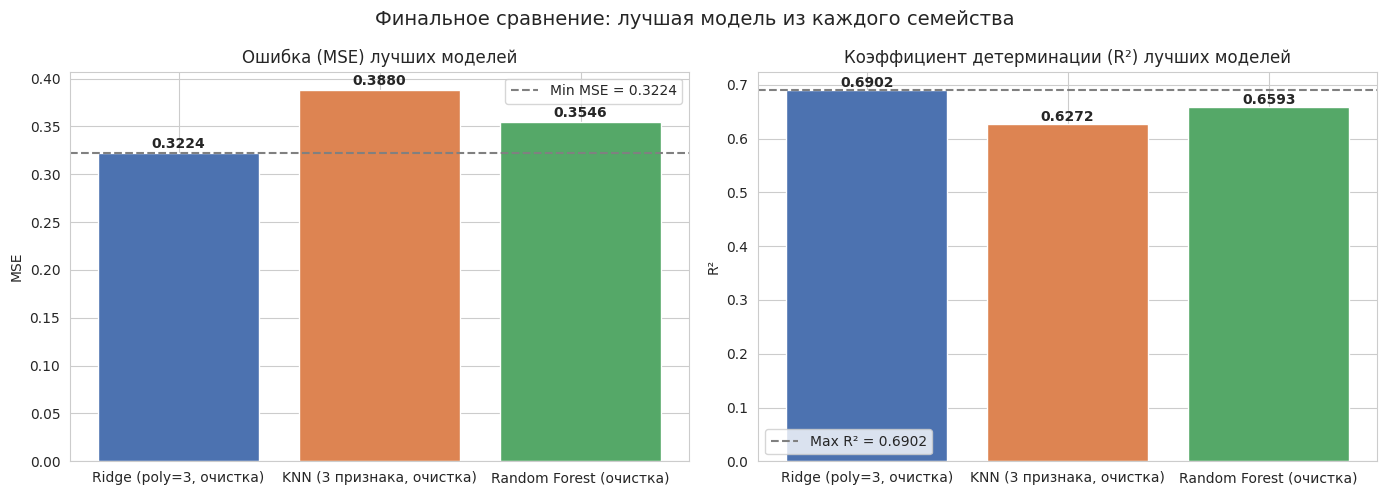

In [ ]:
best_models = pd.DataFrame({
    'Модель': [
        'Ridge (poly=3, очистка)',
        'KNN (3 признака, очистка)',
        'Random Forest (очистка)'
    ],
    'MSE': [mse_clean3, mse_top3, mse_rf_clean],
    'R²':  [r2_clean3, r2_top3, r2_rf_clean]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4c72b0', '#dd8452', '#55a868']

axes[0].bar(best_models['Модель'], best_models['MSE'], color=colors)
axes[0].set_ylabel('MSE')
axes[0].set_title('Ошибка (MSE) лучших моделей')
axes[0].axhline(y=best_models['MSE'].min(), color='gray', linestyle='--',
                label=f'Min MSE = {best_models["MSE"].min():.4f}')
axes[0].legend()
for i, v in enumerate(best_models['MSE']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(best_models['Модель'], best_models['R²'], color=colors)
axes[1].set_ylabel('R²')
axes[1].set_title('Коэффициент детерминации (R²) лучших моделей')
axes[1].axhline(y=best_models['R²'].max(), color='gray', linestyle='--',
                label=f'Max R² = {best_models["R²"].max():.4f}')
axes[1].legend()
for i, v in enumerate(best_models['R²']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Финальное сравнение: лучшая модель из каждого семейства', fontsize=14)
plt.tight_layout()
plt.show()

# Итоговый вывод по проекту

Я провела разведочный анализ данных World Happiness Report 2019, выявила наиболее значимые для индекса счастья признаки (ВВП, социальная поддержка, продолжительность здоровой жизни) и построила несколько регрессионных моделей, последовательно улучшая их. Начав с обычной линейной регрессии, я перешла к полиномиальным признакам и регуляризации (Ridge, Lasso). Лучшей среди линейных моделей стала Ridge-регрессия с полиномами степени 3 и удалением выбросов. Метод k‑ближайших соседей (KNN) я настраивала через подбор гиперпараметров и отбор признаков, но даже его оптимальная версия уступила регуляризованной полиномиальной модели. Случайный лес показал достойный результат, особенно после очистки от выбросов, однако не смог превзойти линейную регрессию. Таким образом, наиболее точной моделью для предсказания индекса счастья на этом наборе данных оказалась Ridge‑регрессия с полиномами степени 3 и удалением выбросов - она лучше всего сбалансировала гибкость и устойчивость на малой выборке.

# Протестируем нашу лучшую модель на реальных данных за 2018 год.

In [ ]:
df_2018 = pd.read_csv('datasets/2018.csv')
df_2018.columns = df_2018.columns.str.replace(' ', '_')

features = [
    'GDP_per_capita',
    'Social_support',
    'Healthy_life_expectancy',
    'Freedom_to_make_life_choices',
    'Generosity',
    'Perceptions_of_corruption'
]

missing = [f for f in features if f not in df_2018.columns]
if missing:
    print("Отсутствуют признаки:", missing)
else:
    df_2018_clean = df_2018.dropna(subset=features + ['Score'])
    print(f"Исходное число стран: {len(df_2018)}")
    print(f"После удаления пропусков: {len(df_2018_clean)}")

    X_2018 = df_2018_clean[features]
    y_2018_true = df_2018_clean['Score']

    X_2018_poly = poly3.transform(X_2018)
    X_2018_scaled = scaler_poly3.transform(X_2018_poly)

    y_2018_pred = ridge_clean3.predict(X_2018_scaled)

    mse_2018 = mean_squared_error(y_2018_true, y_2018_pred)
    r2_2018 = r2_score(y_2018_true, y_2018_pred)

    print("\nПроверка лучшей модели (Ridge, полиномы степени 3, без выбросов) на данных 2018:")
    print(f"MSE = {mse_2018:.4f}")
    print(f"R²  = {r2_2018:.4f}")

    comparison = pd.DataFrame({
        'Страна': df_2018_clean['Country_or_region'].values,
        'Реальный Score': y_2018_true.values,
        'Предсказанный Score': y_2018_pred,
        'Ошибка': np.abs(y_2018_true.values - y_2018_pred)
    })
    print("\nПримеры предсказаний (первые 10 стран):")
    print(comparison.head(10).round(3))

Исходное число стран: 156
После удаления пропусков: 155

Проверка лучшей модели (Ridge, полиномы степени 3, без выбросов) на данных 2018:
MSE = 0.2292
R²  = 0.8152

Примеры предсказаний (первые 10 стран):
        Страна  Реальный Score  Предсказанный Score  Ошибка
0      Finland           7.632                7.235   0.397
1       Norway           7.594                7.412   0.182
2      Denmark           7.555                7.289   0.266
3      Iceland           7.495                7.457   0.038
4  Switzerland           7.487                7.311   0.176
5  Netherlands           7.441                6.948   0.493
6       Canada           7.328                7.101   0.227
7  New Zealand           7.324                7.177   0.147
8       Sweden           7.314                7.074   0.240
9    Australia           7.272                7.214   0.058


Модель довольно успешно перенесена на данные другого года: она сохраняет высокую долю объяснённой и не демонстрирует катастрофического падения точности. Небольшие систематические ошибки для самых счастливых стран связаны, скорее всего, с временныыми сдвигами в распределении Score, а не с дефектами модели. Таким образом, Ridge-регрессия с полиномами степени 3 и очисткой от выбросов показала себя как устойчивый инструмент, способный к межгодовому обобщению.